# Lab 9: Block structure of saddle-point problems

We consider the steady Stokes problem with Dirichlet BCs defined in the unit square domain $\Omega := {[0,1]}^2$ by the following set of equations:
$$ 
\begin{cases}
  -\boldsymbol{\Delta} \boldsymbol{u} + \boldsymbol{\nabla} p = 0, 
  \qquad&\text{in }\Omega, \\
  \boldsymbol{\nabla} \cdot \boldsymbol{u} = 0, 
  \qquad &\text{in }\Omega, \\
  \boldsymbol{u} = 1\boldsymbol{i} + 0\boldsymbol{j}, \qquad&\text{on }\Gamma^{\text{up}} = \{ 0 \le x \le 1, \, y=1 \}, \\
  \boldsymbol{u} = \boldsymbol{0}, \qquad&\text{on }\partial\Omega \backslash \Gamma^{\text{up}}.
\end{cases}
$$

Assemble the block matrix associated to the problem using **the FE stable pair $\mathbb{P}^2-\mathbb{P}^1$**. Solve the system using an **iterative Krylov method**. 

## Numerical solution with FEniCS

In [ ]:
%%capture
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:fenics-packages/fenics
!apt-get update -qq
!apt install -y --no-install-recommends fenics
!rm -rf *

### Import the cbc.block module for block operations

In [ ]:
%%capture
!pip install git+https://bitbucket.org/fenics-apps/cbc.block.git
from dolfin import *
from block import *
from block.dolfin_util import *
from block.iterative import *
from block.algebraic.petsc import *

In [ ]:
# 1. mesh generation
n = 20
mesh = UnitSquareMesh(n, n, 'crossed')

# 2. finite element spaces and BCs
V = VectorFunctionSpace(mesh, 'CG', 2)
Q = FunctionSpace(mesh, 'CG', 1)

def top_boundary(x, on_boundary):
    return on_boundary and near(x[1], 1)

def other_boundary(x, on_boundary):
    return on_boundary and not near(x[1], 1)

bcs = [DirichletBC(V, Constant((1, 0)), top_boundary),
       DirichletBC(V, Constant((0, 0)), other_boundary)]

# 3a. Define variational problem 
v, u = TestFunction(V), TrialFunction(V)
q, p = TestFunction(Q), TrialFunction(Q)

f = Constant((0, 0))

a = inner(grad(v), grad(u))*dx
bT = -div(v)*p*dx
b = -div(u)*q*dx
L1  = dot(v, f)*dx
L2 = Constant(0) * q * dx

In [ ]:
# 3b. Block assembly
A, f1 = assemble_system(a, L1)
BT = assemble(bT)
for bc in bcs:
    bc.apply(A, f1)
    bc.zero(BT)

B = assemble(b)
f2 = assemble(L2)

AA = block_mat([[A, BT], [B, 0]])
bb = block_vec([f1, f2])

ConjGrad NOT CONV. [iter=1000, time=0.77s, res=1.3e+02, true res=1.3e+02]
Norm of velocity coefficient vector: 126.723125790933
Norm of pressure coefficient vector: 30.5084090618032


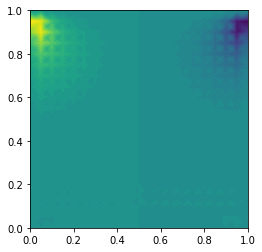

In [ ]:
# 4. Solution using the conjugate gradient method without preconditioner
AAinv = ConjGrad(AA, precond=1.0, tolerance=1e-7, maxiter=1000, show=2)
#AAinv = MinRes(AA, precond=1.0, tolerance=1e-7, maxiter=1000, show=2)
u, p = AAinv * bb

print ("Norm of velocity coefficient vector: %.15g" % u.norm("l2"))
print ("Norm of pressure coefficient vector: %.15g" % p.norm("l2"))

# 5. Plot solution
plot(Function(V, u))
plot(Function(Q, p))

Without preconditioning, the conjugate gradient method does not converge, since the global matrix is semidefinite.

### Preconditioned iterative method

Let's introduce the block diagonal preconditioner
        $$
            P = \begin{bmatrix}A & 0 \\ 0 & M_p\end{bmatrix},
        $$
where $M_p$ is the mass matrix for the pressure unknown.  

Does the number of iterations needed to reach the convergence increase with the number of the elements? (Use a uniformly refined grid with $n=20,\,40,\,80$ subdivisions)

ConjGrad converged [iter=77, time=0.26s, res=6.8e-09, true res=6.1e-09]
Norm of velocity coefficient vector: 15.1331665790656
Norm of pressure coefficient vector: 111.924917542731


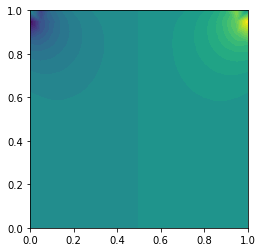

In [ ]:
# 4a. Create preconditioners

Ap = AMG(A)
M  = assemble(p*q*dx)
Mp = InvDiag(M)
#Mp = LumpedInvDiag(M)

PP = block_mat([[Ap, 0], [0, Mp]])

# 4b. Create the block inverse, using the preconditioned CG method
AAinv = ConjGrad(AA, precond=PP, tolerance=1e-8, maxiter=1000, show=2)

# 4c. Compute solution
u, p = AAinv * bb

print ("Norm of velocity coefficient vector: %.15g" % u.norm("l2"))
print ("Norm of pressure coefficient vector: %.15g" % p.norm("l2"))

# 5. Plot solution
plot(Function(V, u))
plot(Function(Q, p))